In [1]:
import os
import itertools
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pymongo import MongoClient
from collections import defaultdict

def get_matches_cursor(uri="mongodb://mongodb:27017/", db_name="riot_data", collection_name="match_summaries", target_version="16.7"):
    """Connects to MongoDB and returns a cursor for the downloaded matches of a specific patch."""
    client = MongoClient(uri)
    col = client[db_name][collection_name]
    return col.find({"status": "downloaded", "game_version": target_version})

def extract_edges(cursor):
    """
    Processes the matches in a single pass to extract both synergy (same team)
    and antagonistic (opposing teams) relationships.
    """
    synergy_edges = defaultdict(int)
    antagonistic_edges = defaultdict(int)

    print("Extracting match data and calculating edge weights...")
    
    for doc in cursor:
        if "data" in doc and "info" in doc["data"]:
            participants = doc["data"]["info"].get("participants", [])
            
            # Split players by team
            team_100 = [p["championName"] for p in participants if p["teamId"] == 100]
            team_200 = [p["championName"] for p in participants if p["teamId"] == 200]
            
            # --- 1. Synergy (Same Team) ---
            # itertools.combinations creates pairs within the same list
            for team in [team_100, team_200]:
                for champ_a, champ_b in itertools.combinations(team, 2):
                    pair = tuple(sorted([champ_a, champ_b]))
                    synergy_edges[pair] += 1
            
            # --- 2. Antagonistic (Opposite Teams) ---
            # itertools.product creates pairs by taking one from team_100 and one from team_200
            for champ_a, champ_b in itertools.product(team_100, team_200):
                pair = tuple(sorted([champ_a, champ_b]))
                antagonistic_edges[pair] += 1

    return synergy_edges, antagonistic_edges

def build_graph(edges_weight_dict, min_threshold):
    """Builds a NetworkX graph, filtering out edges below the threshold and removing isolated nodes."""
    G = nx.Graph()
    
    # Add edges that meet the threshold requirement
    for (champ_a, champ_b), weight in edges_weight_dict.items():
        if weight >= min_threshold:
            G.add_edge(champ_a, champ_b, weight=weight)
            
    # Remove champions that have no connections after filtering
    G.remove_nodes_from(list(nx.isolates(G)))
    
    print(f"Graph generated: {G.number_of_nodes()} champions, {G.number_of_edges()} strong connections.")
    return G

def draw_network(G, icon_folder, gradient_colors, title="Champion Network"):
    """Draws the static graph using Matplotlib, mapping edge weights to a logarithmic color gradient."""
    if G.number_of_edges() == 0:
        print(f"No edges to draw for {title}. Try lowering the threshold.")
        return

    print(f"Drawing {title}...")
    
    fig, ax = plt.subplots(figsize=(20, 20))
    fig.patch.set_facecolor('#121212') 
    ax.set_facecolor('#121212')

    # Calculate node positions using Kamada-Kawai layout
    pos = nx.kamada_kawai_layout(G)

    # Extract edge weights
    edges = G.edges(data=True)
    weights = [d['weight'] for (u, v, d) in edges]

    # Set up the colormap and logarithmic normalization
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", gradient_colors)
    vmax_val = np.percentile(weights, 95) # Cap at the 95th percentile to prevent outliers from breaking the scale
    norm = mcolors.LogNorm(vmin=min(weights), vmax=vmax_val)

    # Apply colors to edges based on weight
    edge_colors = [cmap(norm(w)) for w in weights]

    # Draw edges
    nx.draw_networkx_edges(
        G, pos, ax=ax, 
        width=2,                  
        alpha=0.85,                  
        edge_color=edge_colors      
    )

    # Draw nodes (Champion Icons)
    for node in G.nodes():
        icon_path = os.path.join(icon_folder, f"{node}.png")
        
        if os.path.exists(icon_path):
            img = mpimg.imread(icon_path)
            imagebox = OffsetImage(img, zoom=0.25)
            ab = AnnotationBbox(imagebox, pos[node], frameon=False, pad=0.0)
            ax.add_artist(ab)
        else:
            # Fallback if image is missing
            nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color='#ff3333', node_size=300, ax=ax)
            nx.draw_networkx_labels(G, pos, labels={node: node}, font_color='white', font_size=8, ax=ax)

    plt.axis('off')
    plt.margins(0.0)
    plt.tight_layout()
    plt.title(title, color="white", fontsize=24, pad=20)
    plt.show()

Extracting match data and calculating edge weights...
Graph generated: 70 champions, 261 strong connections.
Drawing Synergy Network (Played Together)...


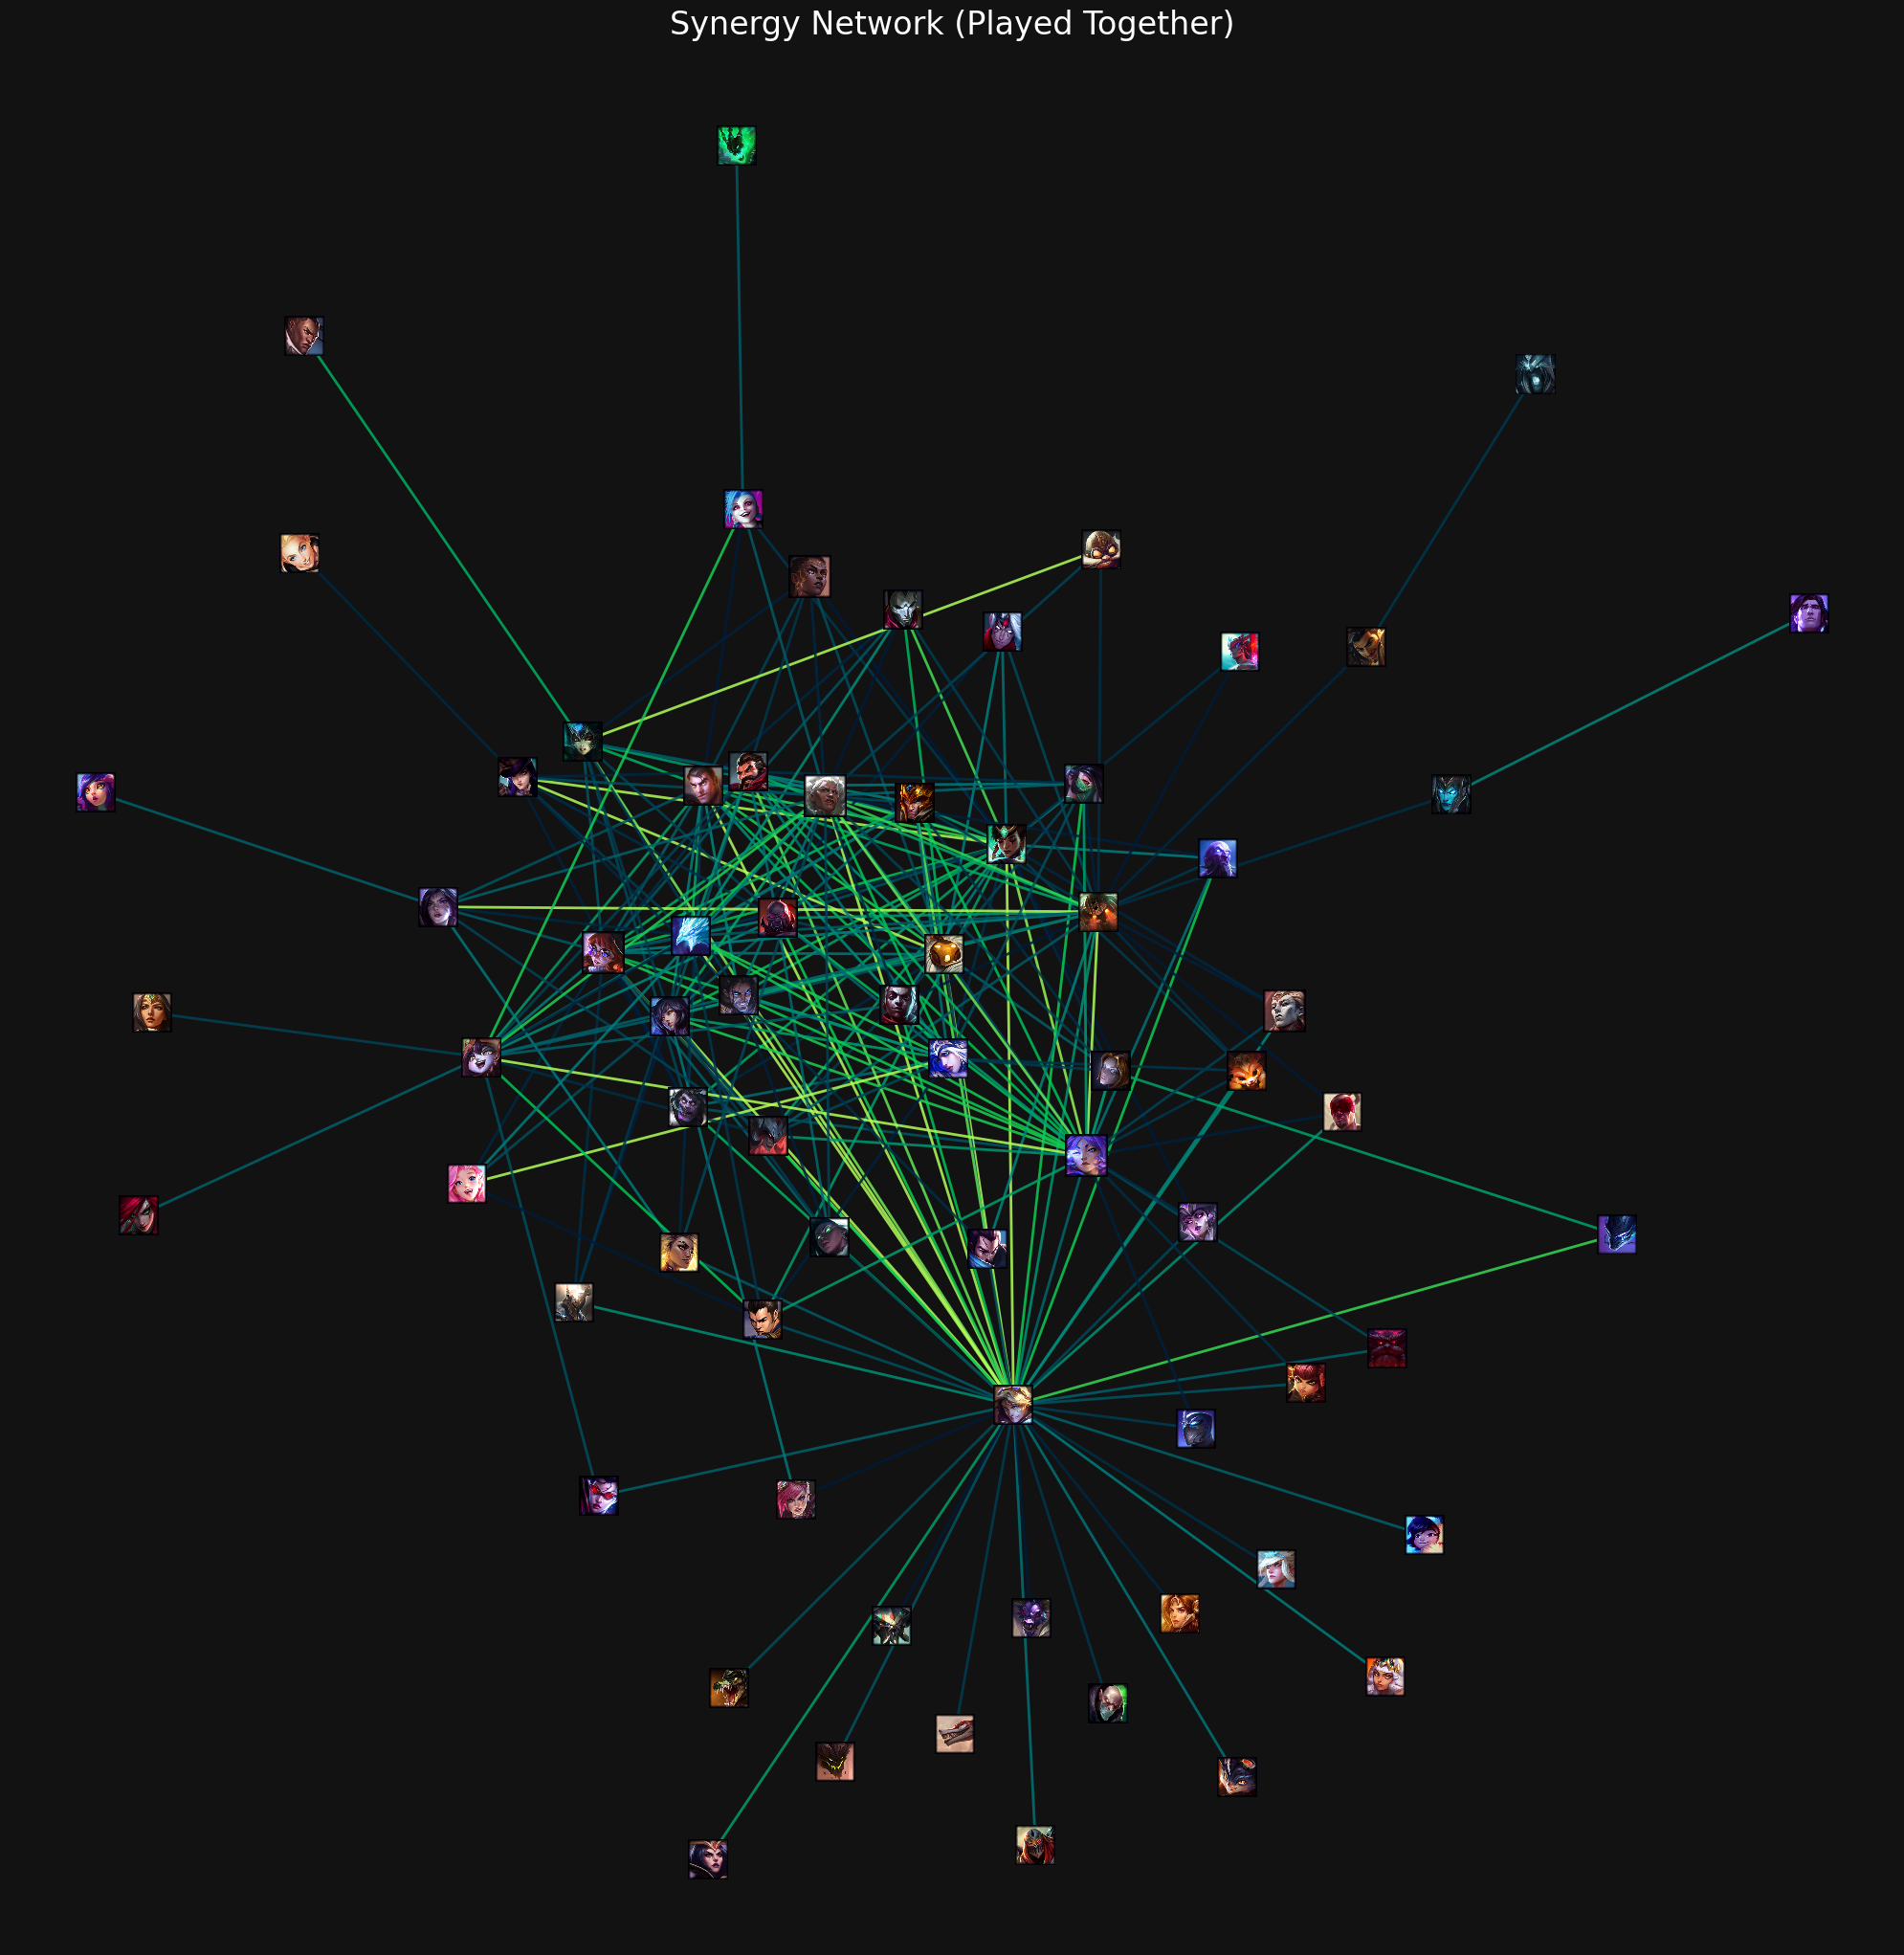

Graph generated: 67 champions, 352 strong connections.
Drawing Antagonistic Network (Played Against)...


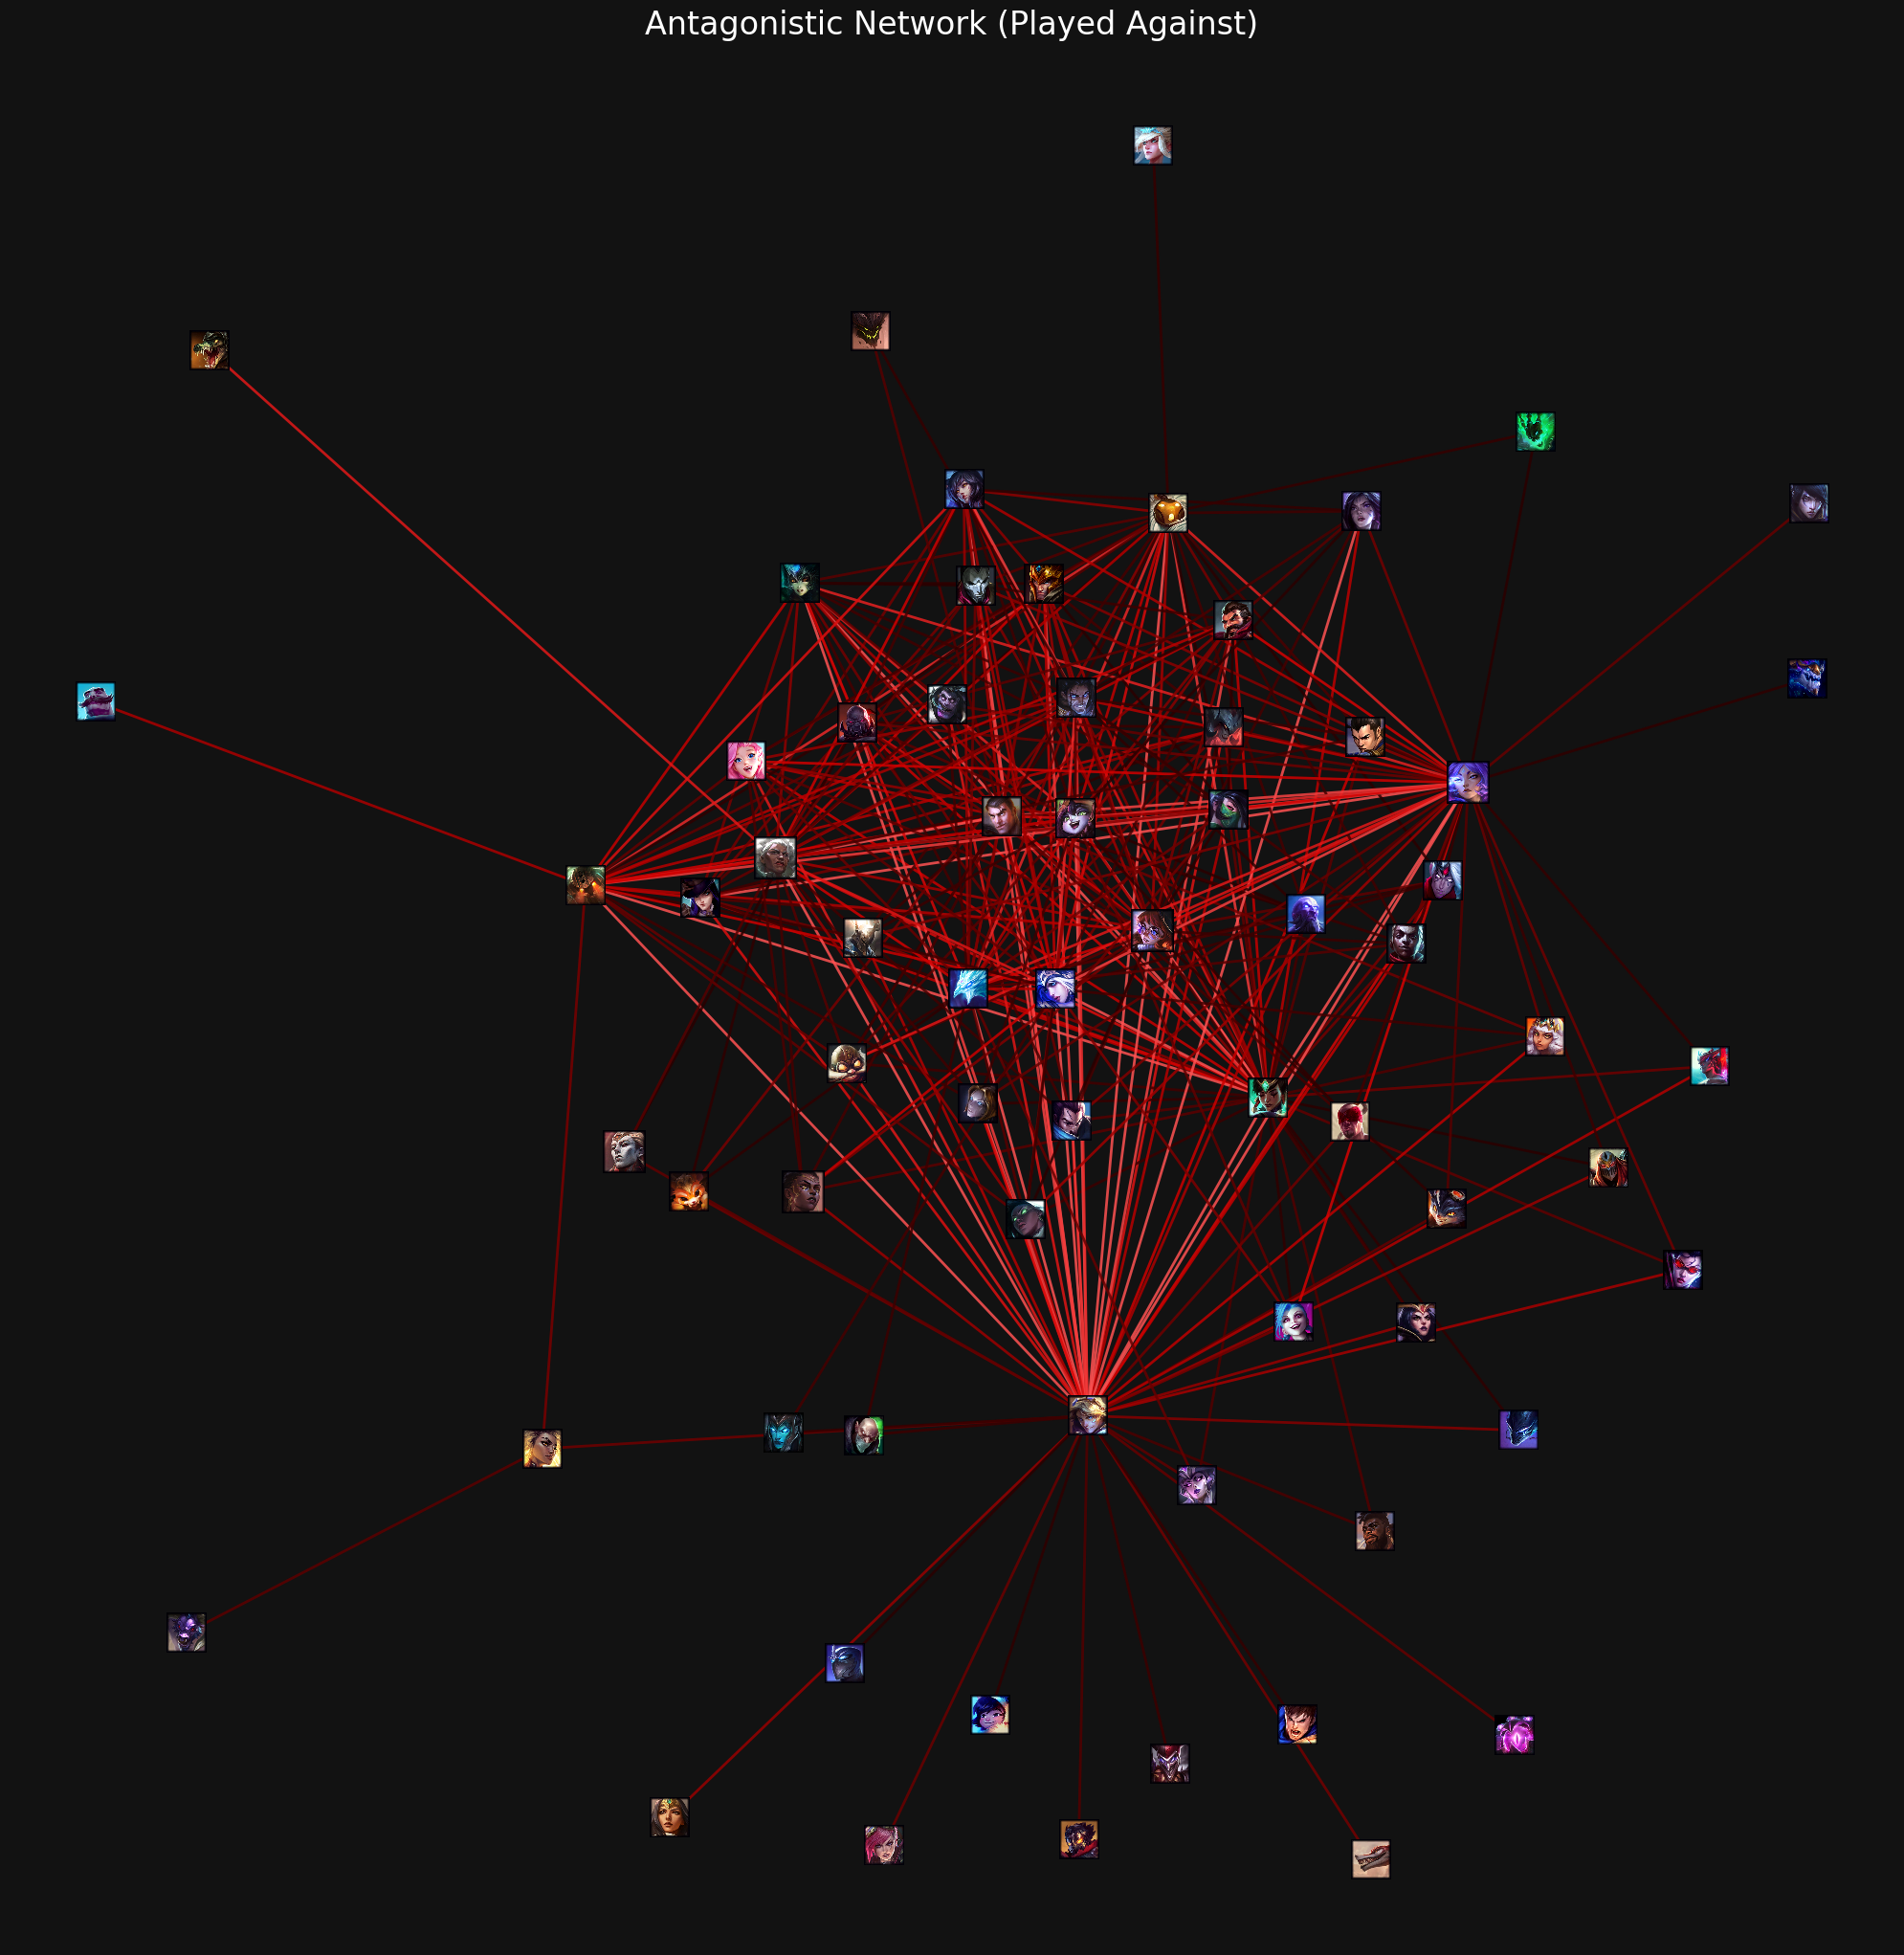

In [2]:
if __name__ == "__main__":
    # Settings
    TARGET_PATCH = "16.7"
    MIN_GAMES = 50
    ICON_DIR = "../data/champion_icons"
    
    # 1. Fetch data
    cursor = get_matches_cursor(target_version=TARGET_PATCH)
    
    # 2. Extract both relationships in a single pass!
    synergy_data, antagonistic_data = extract_edges(cursor)
    
    # --- PLOT 1: SYNERGY GRAPH (Green Gradient) ---
    G_synergy = build_graph(synergy_data, min_threshold=MIN_GAMES)
    synergy_colors = ["#001b3a", "#008080", "#00c853", "#b2ff59"] # Navy -> Teal -> Emerald -> Neon Lime
    
    draw_network(
        G=G_synergy, 
        icon_folder=ICON_DIR, 
        gradient_colors=synergy_colors, 
        title="Synergy Network (Played Together)"
    )
    
    # --- PLOT 2: ANTAGONISTIC GRAPH (Red Gradient) ---
    G_antagonistic = build_graph(antagonistic_data, min_threshold=MIN_GAMES)
    antagonistic_colors = ["#2b0000", "#800000", "#d50000", "#ff5252"] # Dark Maroon -> Crimson -> Red -> Neon Coral
    
    draw_network(
        G=G_antagonistic, 
        icon_folder=ICON_DIR, 
        gradient_colors=antagonistic_colors, 
        title="Antagonistic Network (Played Against)"
    )